# Qubit spectroscopy intrinsic width

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal07_qubit_spectroscopy_intrinsic_width import QubitSpectroscopyIntrinsicWidth

## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "qubit_spectroscopy_intrinsic_width"

QUBITS = ["q10"]
FREQUENCY_CENTER = None  # None: use each qubit's own f01 from the device config
FREQUENCY_WIDTH = 50e6
FREQUENCY_POINTS = 101
MAXIMUM_BRANCH_WIDTH = 800e6
REPETITIONS = 10
# DRIVE_AMPLITUDES = [0.002, 0.05, 0.1, 0.3]
DRIVE_AMPLITUDES = np.arange(start = 0.1, stop = 1, step = 0.01)   # Alternative sweep-like method
DRIVE_DURATION = 20e-6
MAX_DRIVE_POWER_DBM = 0  # Reference power (dBm) at drive_amplitude = 1.0, used to plot power in dBm

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
RESTORE_DRIVE_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None if parameter persistence is not required

## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = QubitSpectroscopyIntrinsicWidth(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Branch plan

In [4]:
for qubit in experiment.qubits:
    center = (
        float(qubit.clock_freqs.f01)
        if FREQUENCY_CENTER is None
        else FREQUENCY_CENTER
    )
    branches = experiment.plan_branches(
        frequency_center=center,
        frequency_width=FREQUENCY_WIDTH,
        frequency_points=FREQUENCY_POINTS,
        maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
    )
    print(f"{qubit.name} (center {center / 1e9:.6f} GHz):")
    for branch in branches:
        print(
            f"  Branch {branch.index + 1}: "
            f"{branch.start / 1e9:.6f}-{branch.stop / 1e9:.6f} GHz, "
            f"LO {branch.lo_frequency / 1e9:.6f} GHz, "
            f"{branch.points} points"
        )

q10 (center 3.549525 GHz):
  Branch 1: 3.524525-3.574525 GHz, LO 3.549525 GHz, 101 points


## Measurement

In [5]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
    repetitions=REPETITIONS,
    drive_amplitudes=DRIVE_AMPLITUDES,
    drive_duration=DRIVE_DURATION,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    restore_drive_lo_frequency=RESTORE_DRIVE_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/mic

<xarray.Dataset> Size: 364kB
Dimensions:              (acq_index_S21_q10: 9090)
Coordinates:
    frequency_q10        (acq_index_S21_q10) float64 73kB 3.525e+09 ... 3.575...
    drive_amplitude_q10  (acq_index_S21_q10) float64 73kB 0.1 0.1 ... 0.99 0.99
  * acq_index_S21_q10    (acq_index_S21_q10) int64 73kB 0 1 2 ... 9087 9088 9089
Data variables:
    S21_q10              (acq_index_S21_q10) complex128 145kB (0.001875450992...
Attributes:
    tuid:     20260908-054713-708-9144be

## 2D Plot

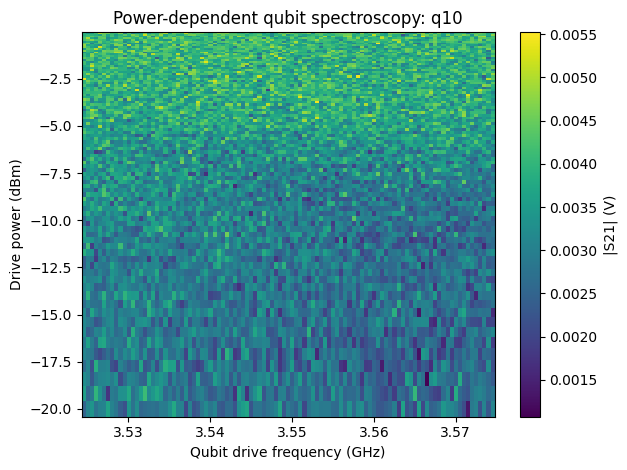

In [6]:
for qubit in QUBITS:
    frequencies = np.asarray(dataset[f"frequency_{qubit}"].values).ravel()
    drive_amplitudes = np.asarray(dataset[f"drive_amplitude_{qubit}"].values).ravel()
    transmission = np.asarray(dataset[f"S21_{qubit}"].values).ravel()

    valid = (
        np.isfinite(frequencies)
        & np.isfinite(drive_amplitudes)
        & np.isfinite(transmission)
    )
    unique_frequencies = np.unique(frequencies[valid])
    unique_amplitudes = np.unique(drive_amplitudes[valid])
    unique_power_dbm = MAX_DRIVE_POWER_DBM + 20 * np.log10(unique_amplitudes)
    frequency_indices = np.searchsorted(unique_frequencies, frequencies[valid])
    amplitude_indices = np.searchsorted(unique_amplitudes, drive_amplitudes[valid])

    transmission_sum = np.zeros(
        (unique_amplitudes.size, unique_frequencies.size),
        dtype=complex,
    )
    sample_count = np.zeros(transmission_sum.shape, dtype=int)
    np.add.at(
        transmission_sum,
        (amplitude_indices, frequency_indices),
        transmission[valid],
    )
    np.add.at(sample_count, (amplitude_indices, frequency_indices), 1)
    averaged_transmission = np.divide(
        transmission_sum,
        sample_count,
        out=np.full(transmission_sum.shape, np.nan + 0j),
        where=sample_count > 0,
    )

    figure, axis = plt.subplots()
    image = axis.pcolormesh(
        unique_frequencies / 1e9,
        unique_power_dbm,
        np.abs(averaged_transmission),
        shading="auto",
    )
    axis.set_xlabel("Qubit drive frequency (GHz)")
    axis.set_ylabel("Drive power (dBm)")
    axis.set_title(f"Power-dependent qubit spectroscopy: {qubit}")
    figure.colorbar(image, ax=axis, label="|S21| (V)")
    figure.tight_layout()
plt.show()

## Analysis

In [17]:
ANALYSIS_DRIVE_AMPLITUDE = 0.3

In [18]:
results = experiment.analysis(drive_amplitude=ANALYSIS_DRIVE_AMPLITUDE)
print(f"Analyzed drive amplitude: {ANALYSIS_DRIVE_AMPLITUDE:.9g}")
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: f01 = {result.frequency / 1e9:.9f} GHz, "
            f"linewidth = {result.linewidth / 1e6:.3f} MHz"
        )
    else:
        print(f"{qubit}: qubit-spectroscopy fit failed")

Analyzed drive amplitude: 0.3
q1: f01 = 2.941108188 GHz, linewidth = 4.698 MHz


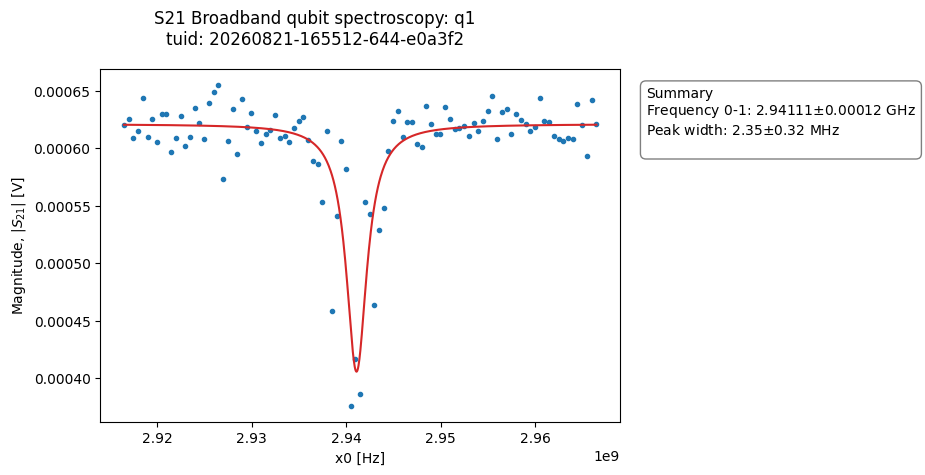

In [19]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [20]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [ ]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()